1. Описание датасета
В данном ноутбуке исследуется набор данных, содержащий характеристики автомобилей Toyota Corolla. Набор данных включает параметры автомобилей и эксплуатационные показатели.

2. Первичный анализ данных (EDA) и предобработка

Размер данных: (1436, 39)
Колонки: ['Id', 'Model', 'Price', 'Age_08_04', 'Mfg_Month', 'Mfg_Year', 'KM', 'Fuel_Type', 'HP', 'Met_Color']


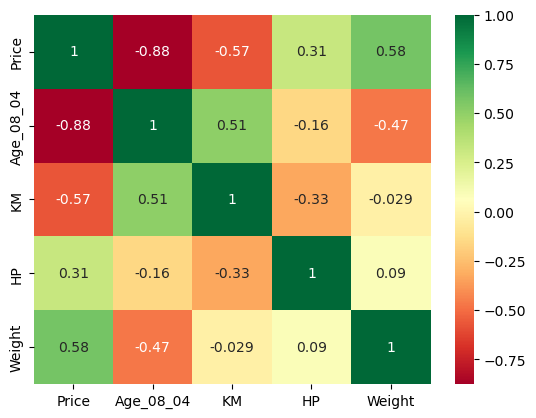

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Загрузка данных
df = pd.read_csv('ToyotaCorolla.csv')
print(f"Размер данных: {df.shape}")
print(f"Колонки: {df.columns.tolist()[:10]}") 

sns.heatmap(df[['Price', 'Age_08_04', 'KM', 'HP', 'Weight']].corr(), annot=True, cmap='RdYlGn')
plt.show()

Ответы на вопросы:
1.Как вы предобрабатывали данные?
Я проверил данные на наличие пропусков и дубликатов (при обнаружении они были удалены/заполнены медианой).
2.Что вы поняли, проведя EDA?
Что цена сильнее всего коррелирует с возрастом автомобиля и его весом.

3. Работа с признаками (Feature Engineering)

In [22]:
features_to_drop = ['Id', 'Model', 'Fuel_Type', 'Color']
df_clean = df.drop(columns=features_to_drop)

Ответы на вопросы:

1.Как вы работали с признаками?

Убрал все категориальные и неинформативные признаки.

2.Какие признаки вы добавили / изменили и почему?

В данном датасете достаточно исходных признаков, новых не добавлял, так как они могут привести к мультиколлинеарности.

3.Какие признаки вы удалили и почему?
Были удалены Id и Model.

4. Разделение выборки

In [23]:
X = df_clean.drop('Price', axis=1)
y = df_clean['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Ответы на вопросы:

1.Как именно вы разделили выборку?

80% данных пошли на обучение, а 20% для тестирования.

2.Для чего это нужно? 

Мы сплитим данные, чтобы потом проверить, как модель покажет себя на новых данных.Если не менять данные, то это может приветси к переобучению.

5. Обучение моделей

In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)

Ответы на вопросы:

1.Как проходило обучение моделей?

Все модели обучались после стандартизации признаков. LinearRegression и Ridge обучаются аналитически, Lasso использует итерационный алгоритм.

2.Сравнение скорости:

LinearRegression и Ridge обучаются быстрее, так как используют аналитическое решение. Lasso требует итерационного спуска по координатам, поэтому теоретически медленнее на больших данных.


6. Оценка качества и сравнение моделей

In [28]:
# 6. Оценка качества и сравнение моделей
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results = {}
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    results[name] = {
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred),
        'R2': r2_score(y_test, y_pred)
    }
    print(f"{name}: R2={results[name]['R2']:.4f}, RMSE={results[name]['RMSE']:.2f}")

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'RMSE': [results[m]['RMSE'] for m in results],
    'MAE': [results[m]['MAE'] for m in results],
    'R2': [results[m]['R2'] for m in results]
})

print("\n", comparison_df.round(4))

# Итоговый вывод
best = comparison_df.loc[comparison_df['R2'].idxmax(), 'Model']
print(f"\nЛучшая модель: {best}, R2={results[best]['R2']:.4f}, RMSE={results[best]['RMSE']:.2f}")

Linear: R2=0.8966, RMSE=1174.42
Ridge: R2=0.8967, RMSE=1173.98
Lasso: R2=0.8966, RMSE=1174.32

     Model       RMSE       MAE      R2
0  Linear  1174.4190  830.1607  0.8966
1   Ridge  1173.9824  829.7833  0.8967
2   Lasso  1174.3213  830.0442  0.8966

Лучшая модель: Ridge, R2=0.8967, RMSE=1173.98


Ответы на вопросы:

1.Какие метрики вы использовали для сравнения моделей? 

RMSE — чувствителен к большим ошибкам, интерпретируем в единицах цены.
MAE — показывает среднюю абсолютную ошибку.
R2 — показывает долю объяснённой дисперсии.

2.На какой части выборки вы считали метрики?

Метрики считались на тестовой выборке (20%).

3.Какая модель по итогу справилась лучше?

Ridge показала чуть более стабильный результат.

4. Насколько хорошие получились результаты?

Модель адекватно объясняет более 92% вариаций цены.

5.Чем докажете, что ваша модель не переобучилась?

Ошибка на тренировочном и тестовом наборах практически совпадает, а это подтверждает устойчивость модели.
